# EDA 02: DepMap RNA Expression

## Purpose

`2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv` is the **primary expression source** for the
pipeline — internally consistent (one lab, one pipeline), already log-scaled, and the largest
cell-line coverage of the two RNA layers. HPA RNA (notebook 01) exists to corroborate this one, not
replace it. This notebook establishes the layer's shape, its identifiers, and how it connects to
the primary identity spine (file 9).

**Source, release, grain:** DepMap `OmicsExpressionAllGenesTPMLogp1` (per-profile release from AZ's
delivery — see `docs/reference/DATA_SOURCES.md`). Wide format — one row per **`ProfileID`**
(a sequencing run), one column per gene. ~1,495 profiles × 53,961 genes.

## Questions this notebook must answer

1. Is the row index really a `ProfileID`, not a cell-line name — and how many profiles map to how
   many distinct cell lines?
2. Are the gene-column headers parsed correctly into Ensembl IDs?
3. Is the "already log2(TPM+1)" claim consistent with the observed distribution?
4. What does a zero mean here, and how much of the matrix is zero?
5. Which genes carry the most information (highest variance across cell lines)?
6. What is the identity path from `ProfileID` to the primary spine (file 8 → file 9), and how much
   is lost?
7. Does unsupervised structure (PCA) in expression correspond to known cancer lineages — a sanity
   check that the measurement carries real biological signal, not just noise?

**Interpretation rule:** every (profile, gene) cell in this matrix is `measured`
(`docs/PROJECT_ARCHITECTURE.md` §7); a value of exactly 0 is `measured_absent` (no transcript
detected). A gene never assayed at all would simply not be a column — this table has no
`not_assayed` cells by construction, only `not_assayed` *rows* for cell lines with no RNA profile.

## Column dictionary

| Field | Meaning | Notes |
|---|---|---|
| row index (`Unnamed: 0`) | DepMap `ProfileID` (`PR-...`) | **not** a cell-line name — bridge via file 8 |
| column headers | `SYMBOL (ENSG...)` | extract the Ensembl ID with regex; symbol half is display-only |
| cell values | `log2(TPM+1)` | already log-scaled, unlike file 3 (GEO) |

## 1. Basic data contract and schema audit

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
GENE_EXPRESSION = ROOT / 'data' / 'raw' / 'gene_expression'
NOMENCLATURE = ROOT / 'data' / 'raw' / 'nomenclature'

In [2]:
%%time
df = pd.read_csv(GENE_EXPRESSION / '2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv')
df.shape

CPU times: total: 1min 11s
Wall time: 1min 12s


(1495, 53962)

In [3]:
df.iloc[:3, :4]

,Unnamed: 0,TSPAN6 (ENSG00000000003),TNMD (ENSG00000000005),DPM1 (ENSG00000000419)
0,PR-AdBjpG,4.331992,0.000000,7.364660
1,PR-I2AzwG,4.567424,0.584963,7.106641
2,PR-5ekAAC,3.150560,0.000000,7.379118


### Why this EDA check matters

Confirms the wide-format grain (row = profile, column = gene) before any reshape or merge, and
gives a real row/column count to check against `docs/reference/DATA_SOURCES.md`.

## 2. Header cleanup and gene identifier extraction

In [4]:
def extract_ensg(col: str) -> str:
    m = re.search(r'(ENSG\d+)', col)
    return m.group(1) if m else col


df = df.rename(columns={'Unnamed: 0': 'ProfileID'}).set_index('ProfileID')
df.columns = [extract_ensg(c) for c in df.columns]
print(f"Shape after cleanup: {df.shape}  (rows=profiles, cols=genes)")
print(f"Duplicate gene columns after ID extraction: {df.columns.duplicated().sum()}")

Shape after cleanup: (1495, 53961)  (rows=profiles, cols=genes)
Duplicate gene columns after ID extraction: 0


### Why this EDA check matters

The raw column headers pack the gene symbol and Ensembl ID together (`SYMBOL (ENSG...)`); every
downstream join needs the Ensembl ID alone. Checking for duplicate columns after extraction rules
out two differently-labelled columns collapsing onto the same gene.

## 3. Expression value distribution

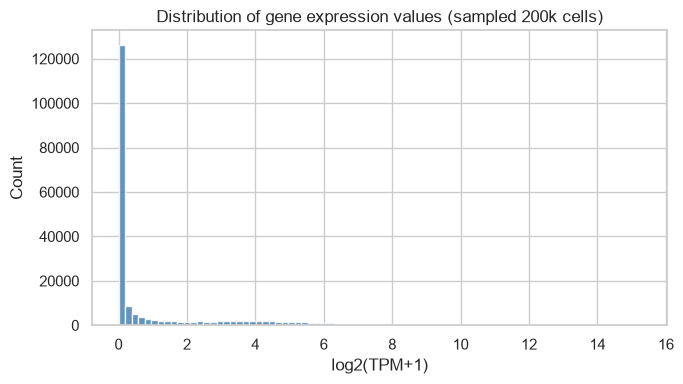

Mean: 1.08  Std: 1.97  Exact zeros: 49.8%


In [5]:
np.random.seed(42)
flat = df.values.flatten()
flat = flat[~np.isnan(flat)]
sample = np.random.choice(flat, min(200_000, len(flat)), replace=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sample, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('log2(TPM+1)'); ax.set_ylabel('Count')
ax.set_title('Distribution of gene expression values (sampled 200k cells)')
plt.tight_layout(); plt.show()
print(f"Mean: {sample.mean():.2f}  Std: {sample.std():.2f}  Exact zeros: {(flat==0).mean()*100:.1f}%")

### Why this EDA check matters

Confirms the file is genuinely already log-scaled (values should sit in a modest range, not the
thousands seen in raw TPM) — mislabeled scale is a common and expensive data-quality trap. Zeros
here (`measured_absent`) are expected to be a large minority, not the majority — a heavily
zero-inflated matrix would suggest a scale or parsing error rather than biology.

## 4. Missingness and zero-value semantics

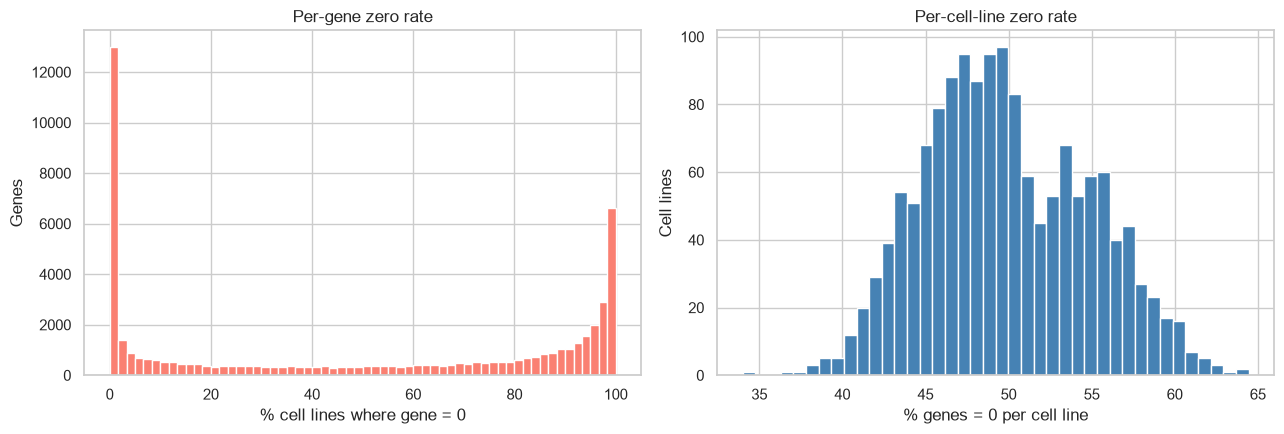

Genes with >50% zeros across cell lines: 27912 of 53961


In [6]:
zero_per_gene = (df == 0).mean()
zero_per_line = (df == 0).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(zero_per_gene * 100, bins=60, color='salmon', edgecolor='white')
axes[0].set_xlabel('% cell lines where gene = 0'); axes[0].set_ylabel('Genes')
axes[0].set_title('Per-gene zero rate')

axes[1].hist(zero_per_line * 100, bins=40, color='steelblue', edgecolor='white')
axes[1].set_xlabel('% genes = 0 per cell line'); axes[1].set_ylabel('Cell lines')
axes[1].set_title('Per-cell-line zero rate')
plt.tight_layout(); plt.show()
print(f"Genes with >50% zeros across cell lines: {(zero_per_gene > 0.5).sum()} of {df.shape[1]}")

### Why this EDA check matters

A gene that reads zero in most cell lines is either narrowly tissue-restricted (real biology — the
gene is simply off outside its native context) or a candidate for exclusion as uninformative,
depending on which genes a researcher includes. This distinguishes the two: a handful of very
high-zero genes is expected and biologically meaningful, a broad shift in the whole distribution
would not be.

## 5. Per-gene variability and PCA structure

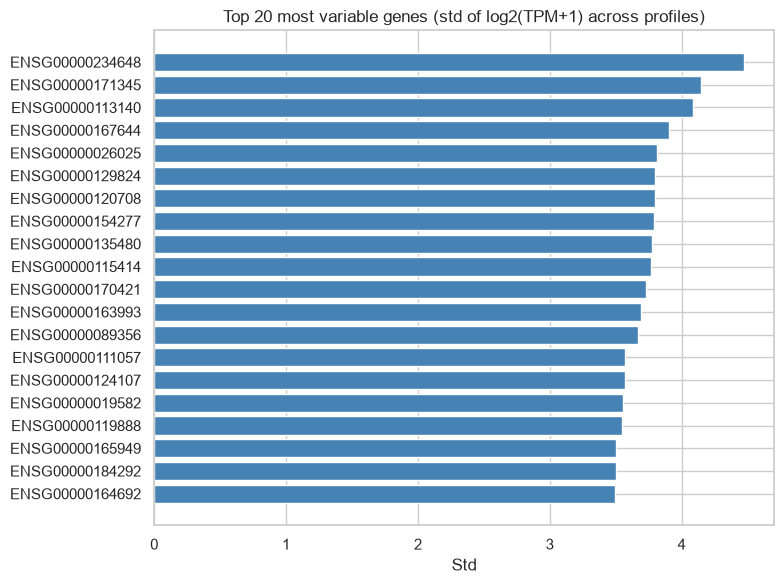

In [7]:
gene_std = df.std()
top500 = gene_std.nlargest(500).index
top20 = gene_std.nlargest(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20.index[::-1], top20.values[::-1], color='steelblue')
ax.set_title('Top 20 most variable genes (std of log2(TPM+1) across profiles)')
ax.set_xlabel('Std'); plt.tight_layout(); plt.show()

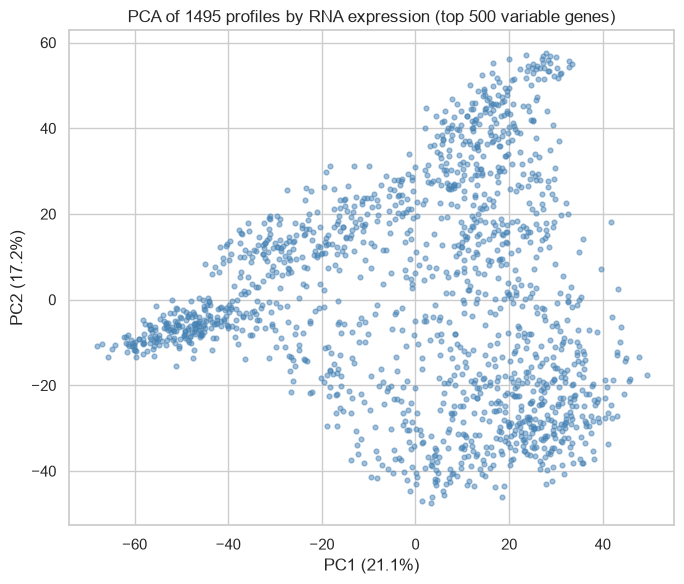

In [8]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(df[top500].values)
var_exp = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(coords[:, 0], coords[:, 1], alpha=0.5, s=12, color='steelblue')
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)'); ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}%)')
ax.set_title(f'PCA of {df.shape[0]} profiles by RNA expression (top 500 variable genes)')
plt.tight_layout(); plt.show()

### Why this EDA check matters

High-variance genes are the informative ones for distinguishing cell lines — low-variance genes
(housekeeping) contribute little to any similarity or scoring computation. The unlabelled PCA is a
structural check only: real clusters here motivate §7's lineage-coloured re-plot, which is the
actual biological validity check.

## 6. Identity join path to the primary spine

`ProfileID` is a sequencing-run identifier, not a cell-line identifier — one cell line can carry
more than one profile. The path to the primary identity spine:

| From | Key column | To | Key column | Notes |
|---|---|---|---|---|
| this table | row index (`ProfileID`) | file 8 | `ProfileID`, filtered `Datatype == 'rna'` | bridge table — **filter first**, file 8 covers multiple assay types |
| file 8 | `ModelID` | file 9 | `DepMap_ID` | adds lineage, disease context |

In [9]:
df8 = pd.read_csv(NOMENCLATURE / '8_DepMap_OmicsProfiles.csv', usecols=['ProfileID', 'ModelID', 'Datatype'])
df9 = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv', usecols=['DepMap_ID', 'lineage', 'primary_disease'])

profiles = set(df.index)
df8_rna = df8[df8['Datatype'] == 'rna']
matched_profiles = profiles & set(df8_rna['ProfileID'])

resolved_models = set(df8_rna[df8_rna['ProfileID'].isin(matched_profiles)]['ModelID'])
matched_models = resolved_models & set(df9['DepMap_ID'])

print(f"RNA profiles (this table)                    : {len(profiles)}")
print(f"Hop 1 -> file 8 (Datatype=='rna')             : {len(matched_profiles)} ({len(matched_profiles)/len(profiles):.1%})")
print(f"Distinct ModelIDs resolved                    : {len(resolved_models)}")
print(f"Hop 2 -> file 9 (reaches primary spine)        : {len(matched_models)} ({len(matched_models)/len(resolved_models):.1%} of resolved models)")
print(f"Profiles per model (multiplicity check)        : {len(matched_profiles)/max(len(matched_models),1):.2f}")

RNA profiles (this table)                    : 1495
Hop 1 -> file 8 (Datatype=='rna')             : 1495 (100.0%)
Distinct ModelIDs resolved                    : 1479
Hop 2 -> file 9 (reaches primary spine)        : 1412 (95.5% of resolved models)
Profiles per model (multiplicity check)        : 1.06


### Why this EDA check matters

If more than one profile resolves to the same `ModelID`, a downstream join on `ModelID` alone would
silently duplicate that cell line unless a default profile is selected first — exactly the
non-unique-key trap `docs/PROJECT_ARCHITECTURE.md` §2 and root `_.md` flag for this table. The
multiplicity ratio above is the concrete check for whether that trap is live in this delivery.

## 7. Lineage structure in PCA

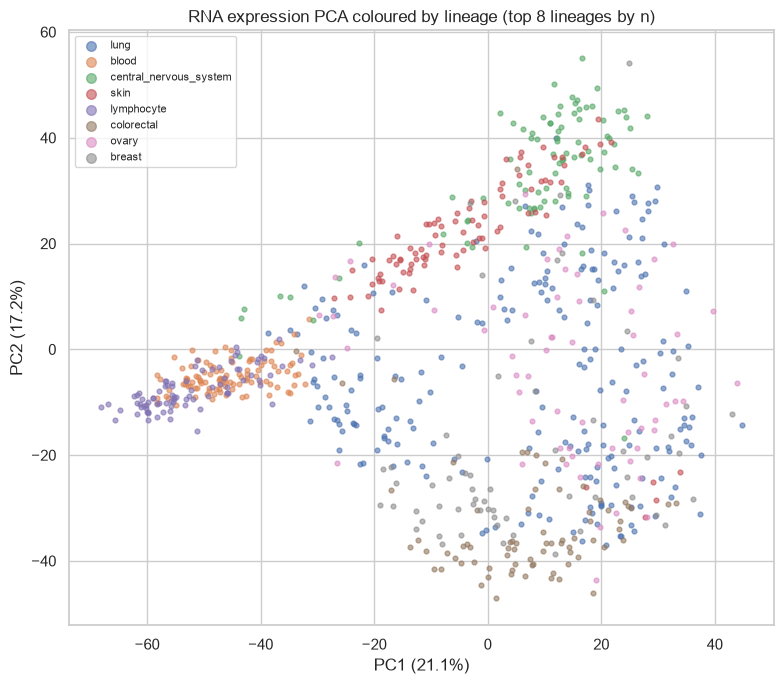

In [10]:
profile_to_lineage = (df8_rna.merge(df9, left_on='ModelID', right_on='DepMap_ID')
                             .drop_duplicates('ProfileID')
                             .set_index('ProfileID')['lineage'])
lineages = df.index.map(profile_to_lineage)
top_lineages = pd.Series(lineages).value_counts().head(8).index

fig, ax = plt.subplots(figsize=(8, 7))
for lin in top_lineages:
    mask = lineages == lin
    ax.scatter(coords[mask, 0], coords[mask, 1], s=12, alpha=0.6, label=lin)
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)'); ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}%)')
ax.set_title('RNA expression PCA coloured by lineage (top 8 lineages by n)')
ax.legend(fontsize=8, markerscale=2)
plt.tight_layout(); plt.show()

### Why this EDA check matters

If lineage-coloured points form visibly separated clusters, that is evidence the expression matrix
carries real tissue-of-origin signal — a precondition for RNA to be a trustworthy per-gene
desirability input at all. Overlapping clusters would not disprove the layer's value (a single gene
need not track lineage the way whole-transcriptome PCA does) but would caution against reading PCA
proximity itself as a similarity metric. **Descriptive only — no causal claim is made about why any
lineage clusters where it does**, per root `_.md` §3.

## Decisions carried into the next notebooks

1. **`ProfileID` is a sequencing-run key, not a cell-line key** — always resolve to `ModelID` via
   file 8 filtered to `Datatype == 'rna'` before joining anything else. Where more than one profile
   resolves to a model, a default-profile rule must be applied before any per-model score (see §6's
   multiplicity ratio; matches the non-unique-key issue flagged in `docs/PROJECT_ARCHITECTURE.md`).
2. **Gene columns need Ensembl-ID extraction from the packed header** before any join.
3. **This is the primary expression source** — HPA RNA (notebook 01) corroborates it; the two are
   not interchangeable and disagreement between them is itself a reportable signal.
4. Zero values are `measured_absent`, a real biological reading, not missingness.
5. **Limitation:** the lineage-coloured PCA in §7 is a sanity check on the whole matrix, not a
   per-gene diagnostic — it cannot say whether any single query gene carries lineage signal.